# Financial Transaction Classifier

### Introduction

### Project Goal: the goal is to build a machine learning model that predicts the category of a financial transaction based on transaction details such as amount, transaction type, account name, and date.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [43]:
df = pd.read_csv("personal_transactions.csv")
df

,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card
...,...,...,...,...,...,...
801,09/27/2019,Biweekly Paycheck,2250.00,credit,Paycheck,Checking
802,09/28/2019,BP,33.46,debit,Gas & Fuel,Platinum Card
803,09/28/2019,Sheetz,4.27,debit,Gas & Fuel,Platinum Card
804,09/30/2019,Starbucks,1.75,debit,Coffee Shops,Platinum Card


In [44]:
df.shape

(806, 6)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB


In [46]:
df.head(10)

,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card
5,01/05/2018,American Tavern,25.85,debit,Restaurants,Silver Card
6,01/06/2018,Hardware Store,18.45,debit,Home Improvement,Silver Card
7,01/08/2018,Gas Company,45.00,debit,Utilities,Checking
8,01/08/2018,Hardware Store,15.38,debit,Home Improvement,Silver Card
9,01/09/2018,Spotify,10.69,debit,Music,Platinum Card


In [47]:
df.describe()

,Amount
count,806.000000
mean,273.391489
std,667.630374
min,1.750000
25%,15.687500
50%,37.480000
75%,117.680000
max,9200.000000


In [48]:
df['Category'].value_counts()

Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Internet                   21
Mortgage & Rent            21
Mobile Phone               21
Music                      21
Movies & DVDs              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64

In [49]:
df.isnull().sum()

Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

no missing values

In [50]:
#convert date column from string to real date

df['Date'] = pd.to_datetime(df['Date'])

In [51]:
#creating new date columns to help model learn patterns (weekend vs weekday spending)

df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek #starts on Monday [0], Tuesday [1]
df['Day'] = df['Date'].dt.day

In [52]:
#keeping only columns that are needed
df_model = df[['Amount', 'Transaction Type', 'Account Name', 'Month', 'DayOfWeek', 'Day', 'Category']].copy()
df_model.head()

,Amount,Transaction Type,Account Name,Month,DayOfWeek,Day,Category
0,11.11,debit,Platinum Card,1,0,1,Shopping
1,1247.44,debit,Checking,1,1,2,Mortgage & Rent
2,24.22,debit,Silver Card,1,1,2,Restaurants
3,2298.09,credit,Platinum Card,1,2,3,Credit Card Payment
4,11.76,debit,Platinum Card,1,3,4,Movies & DVDs


In [53]:
#encode categorical columns
le_type = LabelEncoder()
le_account = LabelEncoder()
le_category = LabelEncoder()

df_model['Transaction Type'] = le_type.fit_transform(df_model['Transaction Type'])
df_model['Account Name'] = le_account.fit_transform(df_model['Account Name'])
df_model['Category'] = le_category.fit_transform(df_model['Category'])

In [83]:
print("Category mapping:")
for i, label in enumerate(le_category.classes_):
    print(i, "->", label)

Category mapping:
0 -> Alcohol & Bars
1 -> Auto Insurance
2 -> Coffee Shops
3 -> Credit Card Payment
4 -> Electronics & Software
5 -> Entertainment
6 -> Fast Food
7 -> Food & Dining
8 -> Gas & Fuel
9 -> Groceries
10 -> Haircut
11 -> Home Improvement
12 -> Internet
13 -> Mobile Phone
14 -> Mortgage & Rent
15 -> Movies & DVDs
16 -> Music
17 -> Paycheck
18 -> Restaurants
19 -> Shopping
20 -> Television
21 -> Utilities


In [54]:
#define features and target
X = df_model[['Amount', 'Transaction Type', 'Account Name', 'Month', 'DayOfWeek', 'Day']]
y = df_model['Category']

In [84]:
#split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



*   80% used for training
*   20% used for testing



In [56]:
#train Decision Tree Model
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [57]:
#smaller decision tree
small_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42
)

small_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

max_depth=3 because it keeps tree from being too complex and helps reduce overfitting

In [58]:
#make predictions
y_pred = model.predict(X_test)

In [59]:
#check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.5493827160493827


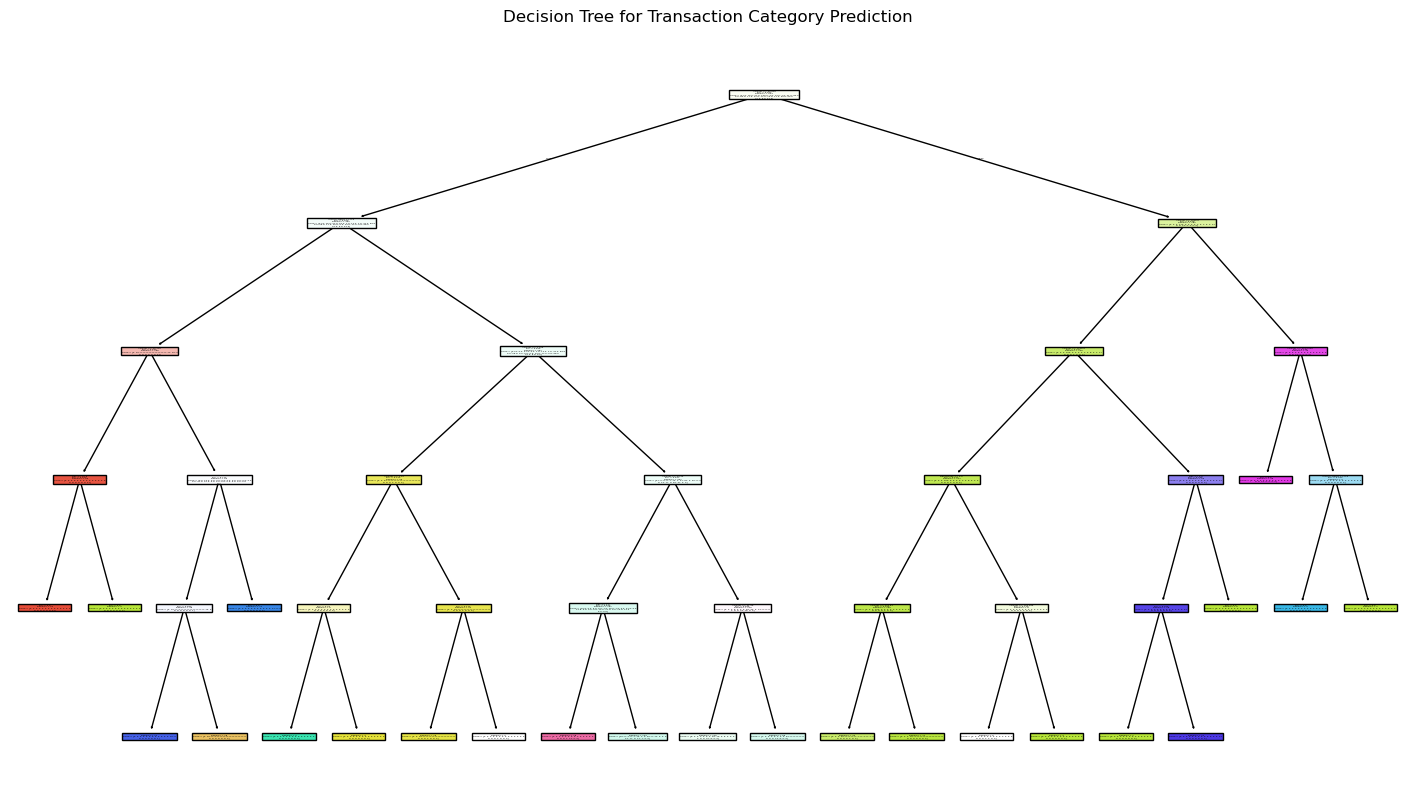

In [60]:
#visualize the Decision Tree
plt.figure(figsize=(18,10))
plot_tree(model, feature_names = X.columns, filled = True)
plt.title("Decision Tree for Transaction Category Prediction")
plt.show()

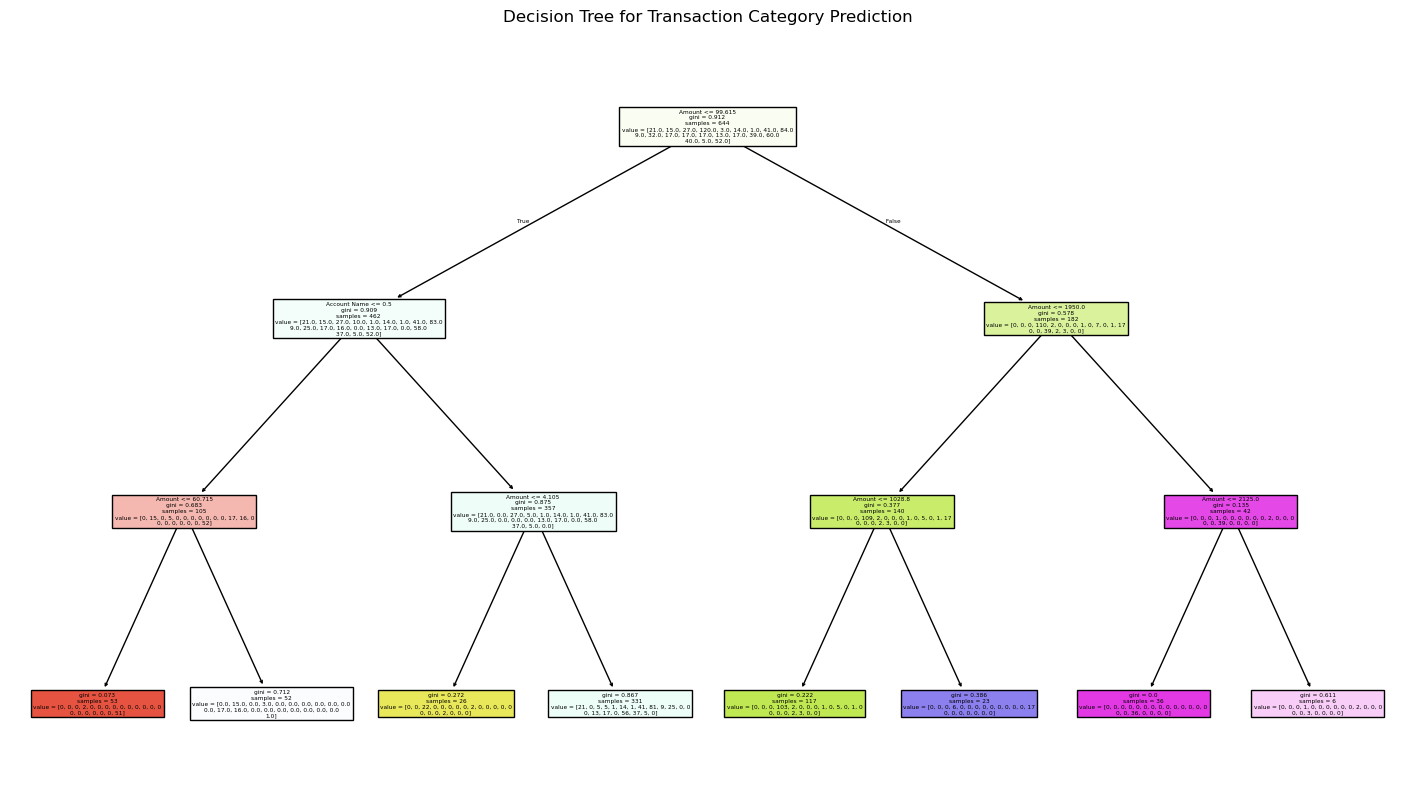

In [62]:
plt.figure(figsize=(18,10))
plot_tree(small_tree, feature_names = X.columns, filled = True)
plt.title("Decision Tree for Transaction Category Prediction")
plt.show()

In [63]:
from sklearn.tree import export_text

rules = export_text(small_tree, feature_names=list(X.columns))
print(rules)

|--- Amount <= 99.62
|   |--- Account Name <= 0.50
|   |   |--- Amount <= 60.72
|   |   |   |--- class: 21
|   |   |--- Amount >  60.72
|   |   |   |--- class: 12
|   |--- Account Name >  0.50
|   |   |--- Amount <= 4.11
|   |   |   |--- class: 2
|   |   |--- Amount >  4.11
|   |   |   |--- class: 9
|--- Amount >  99.62
|   |--- Amount <= 1950.00
|   |   |--- Amount <= 1028.80
|   |   |   |--- class: 3
|   |   |--- Amount >  1028.80
|   |   |   |--- class: 14
|   |--- Amount >  1950.00
|   |   |--- Amount <= 2125.00
|   |   |   |--- class: 17
|   |   |--- Amount >  2125.00
|   |   |   |--- class: 17



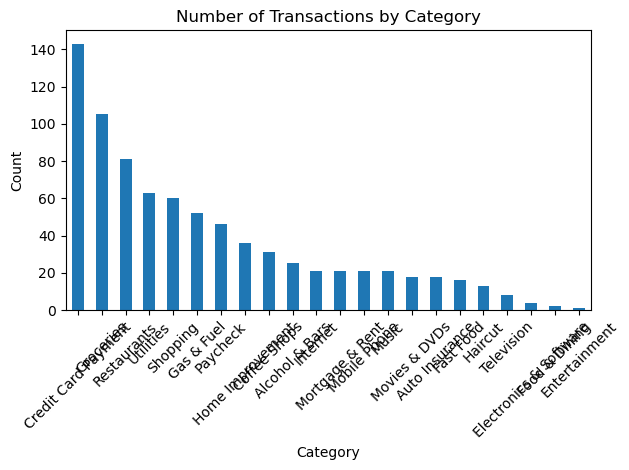

In [64]:
#category distribution chart
category_counts = df['Category'].value_counts()

category_counts.plot(kind='bar')
plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

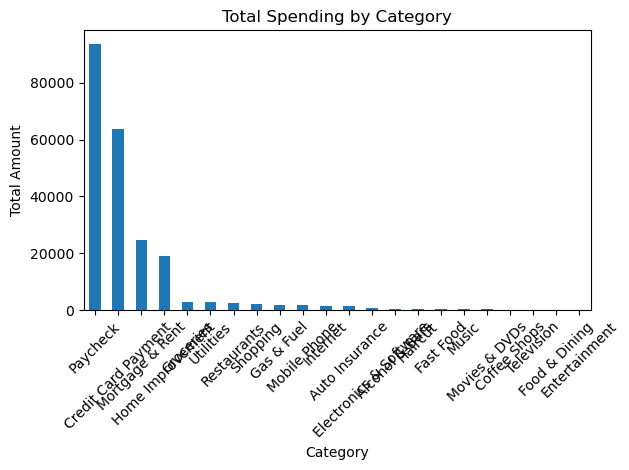

In [65]:
category_spending = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_spending.plot(kind='bar')
plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
#converting Month into text
Month_map = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
df['Month'] = df['Month'].replace(Month_map)

In [67]:
#converting Day of Week into text
DayOfWeek_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['DayOfWeek'] = df['DayOfWeek'].replace(DayOfWeek_map)

In [68]:
#prediction 1
new_transaction = pd.DataFrame({
    'Amount': [12.50],
    'Transaction Type': [le_type.transform(['debit'])[0]],
    'Account Name': [le_account.transform(['Platinum Card'])[0]],
    'Month': [3],
    'DayOfWeek': [1],
    'Day': [15]
})

prediction = model.predict(new_transaction)
predicted_category = le_category.inverse_transform(prediction)

print("Predicted Category:", predicted_category[0])

Predicted Category: Groceries


In [69]:
#prediction 2
new_transaction2 = pd.DataFrame({
    'Amount': [40.00],
    'Transaction Type': [le_type.transform(['debit'])[0]],
    'Account Name': [le_account.transform(['Platinum Card'])[0]],
    'Month': [9],
    'DayOfWeek': [5],
    'Day': [28]
})

prediction2 = model.predict(new_transaction2)
predicted_category2 = le_category.inverse_transform(prediction2)

print("Predicted Category:", predicted_category2[0])

Predicted Category: Gas & Fuel


In [70]:
#prediction 3
new_transaction2 = pd.DataFrame({
    'Amount': [120.00],
    'Transaction Type': [le_type.transform(['debit'])[0]],
    'Account Name': [le_account.transform(['Platinum Card'])[0]],
    'Month': [6],
    'DayOfWeek': [2],
    'Day': [20]
})

prediction2 = model.predict(new_transaction2)
predicted_category2 = le_category.inverse_transform(prediction2)

print("")
print("Predicted Category:", predicted_category2[0])


Predicted Category: Credit Card Payment


In [71]:
df.head(10)

,Date,Description,Amount,Transaction Type,Category,Account Name,Month,DayOfWeek,Day
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,January,Monday,1
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,January,Tuesday,2
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,January,Tuesday,2
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,January,Wednesday,3
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,January,Thursday,4
5,2018-01-05,American Tavern,25.85,debit,Restaurants,Silver Card,January,Friday,5
6,2018-01-06,Hardware Store,18.45,debit,Home Improvement,Silver Card,January,Saturday,6
7,2018-01-08,Gas Company,45.00,debit,Utilities,Checking,January,Monday,8
8,2018-01-08,Hardware Store,15.38,debit,Home Improvement,Silver Card,January,Monday,8
9,2018-01-09,Spotify,10.69,debit,Music,Platinum Card,January,Tuesday,9


In [72]:
from sklearn.tree import export_text

rules = export_text(small_tree, feature_names=list(X.columns))
print(rules)

|--- Amount <= 99.62
|   |--- Account Name <= 0.50
|   |   |--- Amount <= 60.72
|   |   |   |--- class: 21
|   |   |--- Amount >  60.72
|   |   |   |--- class: 12
|   |--- Account Name >  0.50
|   |   |--- Amount <= 4.11
|   |   |   |--- class: 2
|   |   |--- Amount >  4.11
|   |   |   |--- class: 9
|--- Amount >  99.62
|   |--- Amount <= 1950.00
|   |   |--- Amount <= 1028.80
|   |   |   |--- class: 3
|   |   |--- Amount >  1028.80
|   |   |   |--- class: 14
|   |--- Amount >  1950.00
|   |   |--- Amount <= 2125.00
|   |   |   |--- class: 17
|   |   |--- Amount >  2125.00
|   |   |   |--- class: 17



In [73]:
rules = export_text(model, feature_names=list(X.columns))
print(rules)

|--- Amount <= 99.62
|   |--- Account Name <= 0.50
|   |   |--- Amount <= 60.72
|   |   |   |--- Day <= 20.50
|   |   |   |   |--- class: 21
|   |   |   |--- Day >  20.50
|   |   |   |   |--- class: 3
|   |   |--- Amount >  60.72
|   |   |   |--- Day <= 24.00
|   |   |   |   |--- Day <= 14.50
|   |   |   |   |   |--- class: 13
|   |   |   |   |--- Day >  14.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Day >  24.00
|   |   |   |   |--- class: 12
|   |--- Account Name >  0.50
|   |   |--- Amount <= 4.11
|   |   |   |--- Amount <= 2.72
|   |   |   |   |--- Day <= 20.00
|   |   |   |   |   |--- class: 9
|   |   |   |   |--- Day >  20.00
|   |   |   |   |   |--- class: 2
|   |   |   |--- Amount >  2.72
|   |   |   |   |--- DayOfWeek <= 4.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- DayOfWeek >  4.50
|   |   |   |   |   |--- class: 2
|   |   |--- Amount >  4.11
|   |   |   |--- Amount <= 23.12
|   |   |   |   |--- Day <= 1.50
|   |   |   |   |   |--- class: 19
|   |   |

In [74]:
sample = X_test.iloc[[0]]
prediction = small_tree.predict(sample)[0]

node_indicator = small_tree.decision_path(sample)
leaf_id = small_tree.apply(sample)

feature = small_tree.tree_.feature
threshold = small_tree.tree_.threshold

print("Sample values:")
print(sample)

print("\nDecision path:")
node_index = node_indicator.indices[
    node_indicator.indptr[0]:node_indicator.indptr[1]
]

for node_id in node_index:
    if leaf_id[0] == node_id:
        print(f"Reached leaf node {node_id}")
        continue

    feature_name = X.columns[feature[node_id]]
    sample_value = sample.iloc[0, feature[node_id]]
    threshold_value = threshold[node_id]

    if sample_value <= threshold_value:
        decision = "left"
    else:
        decision = "right"

    print(f"Node {node_id}: ({feature_name} = {sample_value}) "
          f"{'<= ' if sample_value <= threshold_value else '> '}"
          f"{threshold_value:.2f} --> go {decision}")

print("\nPredicted category:", prediction)

Sample values:
     Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
697  305.28                 1             0      7          0    8

Decision path:
Node 0: (Amount = 305.28) > 99.62 --> go right
Node 8: (Amount = 305.28) <= 1950.00 --> go left
Node 9: (Amount = 305.28) <= 1028.80 --> go left
Reached leaf node 10

Predicted category: 3


In [75]:
pred_num = small_tree.predict(sample)[0]
pred_label = le_category.inverse_transform([pred_num])[0]

print("Predicted category number:", pred_num)
print("Predicted category name:", pred_label)

Predicted category number: 3
Predicted category name: Credit Card Payment


In [76]:
print("Category mapping:")
for i, label in enumerate(le_category.classes_):
    print(i, "->", label)

Category mapping:
0 -> Alcohol & Bars
1 -> Auto Insurance
2 -> Coffee Shops
3 -> Credit Card Payment
4 -> Electronics & Software
5 -> Entertainment
6 -> Fast Food
7 -> Food & Dining
8 -> Gas & Fuel
9 -> Groceries
10 -> Haircut
11 -> Home Improvement
12 -> Internet
13 -> Mobile Phone
14 -> Mortgage & Rent
15 -> Movies & DVDs
16 -> Music
17 -> Paycheck
18 -> Restaurants
19 -> Shopping
20 -> Television
21 -> Utilities


In [77]:
print("Sample transaction:")
print(sample)

print("\nPrediction path complete ✅")

print("Predicted category number:", pred_num)
print("Predicted category name:", pred_label)

Sample transaction:
     Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
697  305.28                 1             0      7          0    8

Prediction path complete ✅
Predicted category number: 3
Predicted category name: Credit Card Payment


In [78]:
import pandas as pd

def demo_prediction(amount, transaction_type, account_name, month, dayofweek, day):
    # encode the categorical inputs the same way as training
    encoded_type = le_type.transform([transaction_type])[0]
    encoded_account = le_account.transform([account_name])[0]

    # build one-row dataframe in the same feature order as X
    sample = pd.DataFrame([{
        'Amount': amount,
        'Transaction Type': encoded_type,
        'Account Name': encoded_account,
        'Month': month,
        'DayOfWeek': dayofweek,
        'Day': day
    }])

    # predict
    pred_num = small_tree.predict(sample)[0]
    pred_label = le_category.inverse_transform([pred_num])[0]

    # get decision path
    node_indicator = small_tree.decision_path(sample)
    leaf_id = small_tree.apply(sample)

    feature = small_tree.tree_.feature
    threshold = small_tree.tree_.threshold

    print("Sample transaction:")
    print(sample)

    print("\nOriginal transaction values:")
    print({
        "Amount": amount,
        "Transaction Type": transaction_type,
        "Account Name": account_name,
        "Month": month,
        "DayOfWeek": dayofweek,
        "Day": day
    })

    print("\nDecision path:")
    node_index = node_indicator.indices[
        node_indicator.indptr[0]:node_indicator.indptr[1]
    ]

    for node_id in node_index:
        if leaf_id[0] == node_id:
            print(f"Reached leaf node {node_id}")
            continue

        feature_name = X.columns[feature[node_id]]
        sample_value = sample.iloc[0, feature[node_id]]
        threshold_value = threshold[node_id]

        if sample_value <= threshold_value:
            direction = "left"
            symbol = "<="
        else:
            direction = "right"
            symbol = ">"

        print(f"Node {node_id}: ({feature_name} = {sample_value}) {symbol} {threshold_value:.2f} --> go {direction}")

    print("\nPrediction path complete ✅")
    print("Predicted category number:", pred_num)
    print("Predicted category name:", pred_label)

In [79]:
demo_prediction(
    amount=11.11,
    transaction_type='debit',
    account_name='Platinum Card',
    month=1,
    dayofweek=0,
    day=1
)

Sample transaction:
   Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
0   11.11                 1             1      1          0    1

Original transaction values:
{'Amount': 11.11, 'Transaction Type': 'debit', 'Account Name': 'Platinum Card', 'Month': 1, 'DayOfWeek': 0, 'Day': 1}

Decision path:
Node 0: (Amount = 11.11) <= 99.62 --> go left
Node 1: (Account Name = 1) > 0.50 --> go right
Node 5: (Amount = 11.11) > 4.11 --> go right
Reached leaf node 7

Prediction path complete ✅
Predicted category number: 9
Predicted category name: Groceries


In [80]:
demo_prediction(
    amount=24.22,
    transaction_type='debit',
    account_name='Silver Card',
    month=1,
    dayofweek=1,
    day=2
)

Sample transaction:
   Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
0   24.22                 1             2      1          1    2

Original transaction values:
{'Amount': 24.22, 'Transaction Type': 'debit', 'Account Name': 'Silver Card', 'Month': 1, 'DayOfWeek': 1, 'Day': 2}

Decision path:
Node 0: (Amount = 24.22) <= 99.62 --> go left
Node 1: (Account Name = 2) > 0.50 --> go right
Node 5: (Amount = 24.22) > 4.11 --> go right
Reached leaf node 7

Prediction path complete ✅
Predicted category number: 9
Predicted category name: Groceries


In [81]:
demo_prediction(
    amount=2298.09,
    transaction_type='credit',
    account_name='Platinum Card',
    month=1,
    dayofweek=2,
    day=3
)

Sample transaction:
    Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
0  2298.09                 0             1      1          2    3

Original transaction values:
{'Amount': 2298.09, 'Transaction Type': 'credit', 'Account Name': 'Platinum Card', 'Month': 1, 'DayOfWeek': 2, 'Day': 3}

Decision path:
Node 0: (Amount = 2298.09) > 99.62 --> go right
Node 8: (Amount = 2298.09) > 1950.00 --> go right
Node 12: (Amount = 2298.09) > 2125.00 --> go right
Reached leaf node 14

Prediction path complete ✅
Predicted category number: 17
Predicted category name: Paycheck


In [82]:
example_transactions = [
    (11.11, 'debit', 'Platinum Card', 1, 0, 1),
    (24.22, 'debit', 'Silver Card', 1, 1, 2),
    (1247.44, 'debit', 'Checking', 1, 1, 2),
    (2298.09, 'credit', 'Platinum Card', 1, 2, 3),
    (11.76, 'debit', 'Platinum Card', 1, 3, 4)
]

for ex in example_transactions:
    print("\n" + "="*60)
    demo_prediction(*ex)


Sample transaction:
   Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
0   11.11                 1             1      1          0    1

Original transaction values:
{'Amount': 11.11, 'Transaction Type': 'debit', 'Account Name': 'Platinum Card', 'Month': 1, 'DayOfWeek': 0, 'Day': 1}

Decision path:
Node 0: (Amount = 11.11) <= 99.62 --> go left
Node 1: (Account Name = 1) > 0.50 --> go right
Node 5: (Amount = 11.11) > 4.11 --> go right
Reached leaf node 7

Prediction path complete ✅
Predicted category number: 9
Predicted category name: Groceries

Sample transaction:
   Amount  Transaction Type  Account Name  Month  DayOfWeek  Day
0   24.22                 1             2      1          1    2

Original transaction values:
{'Amount': 24.22, 'Transaction Type': 'debit', 'Account Name': 'Silver Card', 'Month': 1, 'DayOfWeek': 1, 'Day': 2}

Decision path:
Node 0: (Amount = 24.22) <= 99.62 --> go left
Node 1: (Account Name = 2) > 0.50 --> go right
Node 5: (Amount = 24.22) > 4.